# I - Preamble

**July 2026 - Ana Rita Carvalho**

(ana.rita.carvalho@tecnico.ulisboa.pt)

This notebook uses Energy Flow Polynomials in different classification models. The datasets used for computing the EFPs and training the models correspond to a dijet background and a di-higgs hh-4b signal (available [here](https://data.mendeley.com/datasets/v9z86dp9mv/1))

In [2]:
# Import packages
#import shap
import uproot
import energyflow as ef
import numpy as np
import awkward as ak
import vector
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

import tensorflow as tf
from tensorflow import keras as tf_keras
from energyflow.datasets import qg_jets
from energyflow.utils import to_categorical
from energyflow.archs import PFN


from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


from tqdm.notebook import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras import layers, losses
from tensorflow.keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import pad_sequences
from keras import backend as K

import random
import itertools as it
import time
import joblib
from datetime import datetime

2026-07-24 16:12:37.756428: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Define path for background and signal files
bkg_path = "/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/data/dijet_200_ntuple.root"
sig_path = "/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/data/hh4b_200_ntuple.root"

# II - Read files

In [4]:
# Open root file with dijet background and hh4b signal events with uproot
bkg_file = uproot.open(bkg_path)
sig_file = uproot.open(sig_path)
bkg_ntuple = bkg_file["ntuple"]
sig_ntuple = sig_file["ntuple"]

In [5]:
# Retrieve TTree 'ntuple' where the background data is stored and check the existing variables
bkg_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

In [6]:
# Retrieve TTree 'ntuple' where the signal data is stored and check the existing variables
sig_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

# III - Retrieve features

## 1- Offline Jets

Reco jets were reconstructed using the anti-kT algorithm, and are used as a proxy for the offline reconstruction.

In [7]:
# Retrieve events as awkward arrays of hadronic coordinates [E, eta, phi] and other relevant features
bkg_events = bkg_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])
sig_events = sig_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])

In [8]:
# _events is an array of events where each event has several arrays, each corresponding to one feature
sig_events

<Array [{eventNumber: 0, ...}, ..., {...}] type='100000 * {eventNumber: int...'>

In [9]:
# Check if the jets in the events are ordered by pT (they are not)
sig_events[5]['akt_energy']

<Array [62.7, 55.1, 48.8, 47.2, ..., 23.3, 22.3, 24.9] type='17 * float32'>

In [10]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()
background = ak.zip(
    {
        "nJets": bkg_events.akt_len,
        "pt": bkg_events.akt_energy,
        "eta": bkg_events.akt_eta,
        "phi": bkg_events.akt_phi,
        "Pileup": bkg_events.akt_isPileup,
        "Flavour": bkg_events.akt_flavor,
        "ConeEnergy": bkg_events.akt_cone04Energy,
        "ring34Energy": bkg_events.akt_cone34Energy,
        "ring12Energy": bkg_events.akt_cone12Energy,
        "mass": ak.zeros_like(bkg_events.akt_energy)
}, with_name="Momentum4D")

signal = ak.zip(
    {
        "nJets": sig_events.akt_len,
        "pt": sig_events.akt_energy,
        "eta": sig_events.akt_eta,
        "phi": sig_events.akt_phi,
        "Pileup": sig_events.akt_isPileup,
        "Flavour": sig_events.akt_flavor,
        "ConeEnergy": sig_events.akt_cone04Energy,
        "ring34Energy": sig_events.akt_cone34Energy,
        "ring12Energy": sig_events.akt_cone12Energy,
        "mass": ak.zeros_like(sig_events.akt_energy)
}, with_name="Momentum4D")

# Retrieve the rapidity from the vectors
bkg_y  = background.rapidity
sig_y  = signal.rapidity

# Add y to the arrays
background = ak.with_field(background, bkg_y, "y")
signal = ak.with_field(signal, sig_y, "y")

## 2 - Trigger Jets

Trigger jets were reconstructed using a simplified sliding window algorithm, and are used as a proxy for the L1 trigger reconstruction.

In [11]:
# Retrieve events features as awkward arrays
bkg_events_sw = bkg_ntuple.arrays(['sw_cone04Energy', 'sw_cone34Energy','sw_cone12Energy', 'sw_eta', 'sw_phi', 'sw_isAKTMatched', 'sw_aktEnergy', 'sw_len'])
sig_events_sw = sig_ntuple.arrays(['sw_cone04Energy', 'sw_cone34Energy', 'sw_cone12Energy','sw_eta', 'sw_phi', 'sw_isAKTMatched', 'sw_aktEnergy', 'sw_len'])

In [12]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()

background_sw = ak.zip(
    {
        "nJets": bkg_events_sw.sw_len,
        "isMatched": bkg_events_sw.sw_isAKTMatched,
        "pt": bkg_events_sw.sw_cone04Energy,
        "ring34Energy": bkg_events_sw.sw_cone34Energy,
        "ring12Energy": bkg_events_sw.sw_cone12Energy,
        "aktEnergy": bkg_events_sw.sw_aktEnergy,
        "eta": bkg_events_sw.sw_eta,
        "phi": bkg_events_sw.sw_phi,
        "mass": ak.zeros_like(bkg_events_sw.sw_cone04Energy)
    }, with_name="Momentum4D"
)

signal_sw = ak.zip(
    {
        "nJets": sig_events_sw.sw_len,
        "isMatched": sig_events_sw.sw_isAKTMatched,
        "pt": sig_events_sw.sw_cone04Energy,
        "ring34Energy": sig_events_sw.sw_cone34Energy,
        "ring12Energy": sig_events_sw.sw_cone12Energy,
        "aktEnergy": sig_events_sw.sw_aktEnergy,
        "eta": sig_events_sw.sw_eta,
        "phi": sig_events_sw.sw_phi,
        "mass": ak.zeros_like(sig_events_sw.sw_cone04Energy)
    }, with_name="Momentum4D"
)

# Add y to the arrays
bkg_y_sw  = background_sw.rapidity
sig_y_sw  = signal_sw.rapidity

background_sw = ak.with_field(background_sw, bkg_y_sw, "y")
signal_sw = ak.with_field(signal_sw, sig_y_sw, "y")

In [13]:
# Check final structure of the events
background_sw[0]

<MomentumArray4D [{nJets: 54, isMatched: 0, ...}, ...] type='54 * Momentum4...'>

## 3 - Order jets by pT (offline)

In [9]:
# Retrieve events as pandas DataFrames
background_df = bkg_ntuple.arrays(['akt_energy', 'akt_eta', 'akt_phi', 'eventNumber', 'akt_len','akt_isPileup', 'akt_flavor'], library="pd")
signal_df = sig_ntuple.arrays(['akt_energy', 'akt_eta', 'akt_phi', 'eventNumber', 'akt_len','akt_isPileup','akt_flavor'], library="pd")

In [10]:
# Check the result
background_df

,akt_energy,akt_eta,akt_phi,eventNumber,akt_len,akt_isPileup,akt_flavor
0,"[56.376060485839844, 49.61208724975586, 40.160...","[0.21851412951946259, -2.463587999343872, -0.5...","[2.961843252182007, -1.0293755531311035, -1.14...",0,15,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, ...","[21.0, 0.0, 0.0, 21.0, 0.0, 21.0, 0.0, 21.0, 0..."
1,"[47.2717399597168, 42.15198516845703, 39.39305...","[0.9015454053878784, 0.39258599281311035, -0.6...","[-2.9753336906433105, 2.4122893810272217, 1.81...",1,12,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 21.0, 21.0..."
2,"[77.32997131347656, 65.49691772460938, 59.8499...","[-0.635909378528595, -0.3734756112098694, -0.0...","[-2.6921324729919434, -0.6759181618690491, -2....",2,19,"[1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 1.0, 0.0, 21.0..."
3,"[53.57494354248047, 50.59023666381836, 50.2220...","[-1.0694591999053955, -1.3038361072540283, -1....","[-2.639137029647827, 0.3129067122936249, 1.044...",3,10,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, ...","[2.0, 21.0, 21.0, 21.0, 21.0, 0.0, 21.0, 0.0, ..."
4,"[52.21803283691406, 49.723968505859375, 38.353...","[-1.3898849487304688, -1.1118090152740479, 0.6...","[2.145557403564453, -0.0785595253109932, 2.994...",4,16,"[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, ...","[0.0, 0.0, 21.0, 21.0, 0.0, 0.0, 0.0, 0.0, 0.0..."
...,...,...,...,...,...,...,...
99995,"[51.92322540283203, 54.798622131347656, 52.258...","[3.175819158554077, 0.20312269032001495, -0.28...","[-2.738940477371216, 1.4623088836669922, 2.618...",99995,15,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 3.0, 21.0, 21.0, 2.0, 3.0, 21.0, 21.0, 0..."
99996,"[45.12558364868164, 46.88414001464844, 37.9416...","[-2.9548678398132324, -0.5077465772628784, -0....","[0.03712071478366852, -2.593989133834839, -1.9...",99996,12,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 21.0, 21.0, 1.0, 0.0, 21.0, 21.0, 21.0, ..."
99997,"[57.99683380126953, 38.15359878540039, 37.2110...","[-1.5791735649108887, -3.212261199951172, 2.07...","[0.709058403968811, -0.9951223731040955, -1.63...",99997,12,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 21.0..."
99998,"[47.493064880371094, 44.485530853271484, 39.10...","[-0.23593087494373322, 0.7516812682151794, -0....","[0.8830403685569763, -0.44237232208251953, 1.9...",99998,15,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[21.0, 21.0, 21.0, 21.0, 0.0, 2.0, 0.0, 0.0, 2..."


In [ ]:
# For each event in the DataFrame, sort jets by pt, add a list of event data to the array of all events
# and calculate the invariant mass of the four b-labelled jets (if they exist)

background_ordered = []
true_mHH_bkg = []

for event in range(len(background_df)):
  # Retrieve event data into a DataFrame with jet features as columns and
  # number of rows = number of jets in the event
  event_data = background_df.iloc[event]
  df = pd.DataFrame({"pt": event_data['akt_energy'], "y": event_data['akt_eta'], "phi": event_data['akt_phi'], "flavour": event_data['akt_flavor']})
  # Sort jets by pT
  df = df.sort_values(by=['pt'], ascending=False)
  jets_list = df.values.tolist()
  # Add sorted jets to list of events
  background_ordered.append(jets_list)

  # Select b-labelled jets in the event
  b_jets = df[df['flavour'] == 5]
  b_jets_list = b_jets.values.tolist()
  # Compute four-jet invariant mass for events with (at least) 4 b-labelled jets
  if len(b_jets_list) >= 4:
    # Retrive the four leading b-labelled jets as vector objects
    b1 = vector.obj(pt=b_jets_list[0][0], eta=b_jets_list[0][1], phi=b_jets_list[0][2], mass=0)
    b2 = vector.obj(pt=b_jets_list[1][0], eta=b_jets_list[1][1], phi=b_jets_list[1][2], mass=0)
    b3 = vector.obj(pt=b_jets_list[2][0], eta=b_jets_list[2][1], phi=b_jets_list[2][2], mass=0)
    b4 = vector.obj(pt=b_jets_list[3][0], eta=b_jets_list[3][1], phi=b_jets_list[3][2], mass=0)
    # Sum the four vectors and retrieve vector mass
    bbbb = b1 + b2 + b3 + b4
    true_mHH_bkg.append(bbbb.mass)
  # Placeholder for events with less than 4 b-labelled jets
  else:
    true_mHH_bkg.append(0)

# Repeat for signal events
signal_ordered = []
true_mHH_sig = []

for event in range(len(signal_df)):
  event_data = signal_df.iloc[event]
  df = pd.DataFrame({"pt": event_data['akt_energy'], "y": event_data['akt_eta'], "phi": event_data['akt_phi'], "flavour": event_data['akt_flavor']})
  df = df.sort_values(by=['pt'], ascending=False)
  jets_list = df.values.tolist()
  signal_ordered.append(jets_list)
  b_jets = df[df['flavour'] == 5]
  b_jets_list = b_jets.values.tolist()
  if len(b_jets_list) >= 4:
    b1 = vector.obj(pt=b_jets_list[0][0], eta=b_jets_list[0][1], phi=b_jets_list[0][2], mass=0)
    b2 = vector.obj(pt=b_jets_list[1][0], eta=b_jets_list[1][1], phi=b_jets_list[1][2], mass=0)
    b3 = vector.obj(pt=b_jets_list[2][0], eta=b_jets_list[2][1], phi=b_jets_list[2][2], mass=0)
    b4 = vector.obj(pt=b_jets_list[3][0], eta=b_jets_list[3][1], phi=b_jets_list[3][2], mass=0)
    bbbb = b1 + b2 + b3 + b4
    true_mHH_sig.append(bbbb.mass)
  else:
    true_mHH_sig.append(0)

In [14]:
# (Run once) Save invariant mass arrays
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_bkg.npy', true_mHH_bkg)
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_sig.npy', true_mHH_sig)

# IV - Plot features

Plot some of the features to compare offline and trigger jets for signal and background data.

In [14]:
# Increase font size (needed to use plots in reports)
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

## 1 - Jet Multiplicity

In [ ]:
# Retrieve jet number for signal and background events
sig_jet_number = sig_ntuple.arrays(['akt_len'])
bkg_jet_number = bkg_ntuple.arrays(['akt_len'])

# Convert to array
jet_number_offline_sig = [event['akt_len'] for event in ak.to_list(sig_jet_number)]
jet_number_offline_bkg = [event['akt_len'] for event in ak.to_list(bkg_jet_number)]

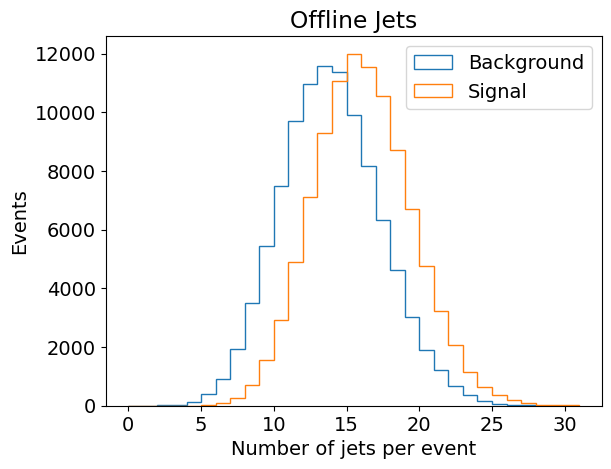

In [ ]:
# Plot jet multiplicity (offline jets)
plt.hist(jet_number_offline_bkg, bins=range(32), histtype='step', label='Background')
plt.hist(jet_number_offline_sig, bins=range(32), histtype='step',label='Signal')
plt.xlabel('Number of jets per event')
plt.ylabel('Events')
plt.title('Offline Jets')
plt.legend()
plt.show()

In [ ]:
# Compute total number of offline jets
totalNjets_offline_bkg = np.sum(jet_number_offline_bkg)
totalNjets_offline_sig = np.sum(jet_number_offline_sig)
print(f'Total number of offline jets in the background: {totalNjets_offline_bkg}')
print(f'Total number of offline jets in the signal: {totalNjets_offline_sig}')

Total number of offline jets in the background: 1343218
Total number of offline jets in the signal: 1562989


In [ ]:
# Check how many signal events have at least 4 jets
jet_number_offline_sig = np.array(jet_number_offline_sig)
condlist = [jet_number_offline_sig >= 4]
choicelist = [1]
sig_events_4jets = np.select(condlist, choicelist, 0)
print(f'Number of signal events with at least 4 jets: {np.sum(sig_events_4jets)}')

Number of signal events with at least 4 jets: 99999


In [ ]:
# Retrieve trigger jet number for signal and background events
sig_jet_number = sig_ntuple.arrays(['sw_len'])
bkg_jet_number = bkg_ntuple.arrays(['sw_len'])

# Convert to array
jet_number_trigger_sig = [event['sw_len'] for event in ak.to_list(sig_jet_number)]
jet_number_trigger_bkg = [event['sw_len'] for event in ak.to_list(bkg_jet_number)]

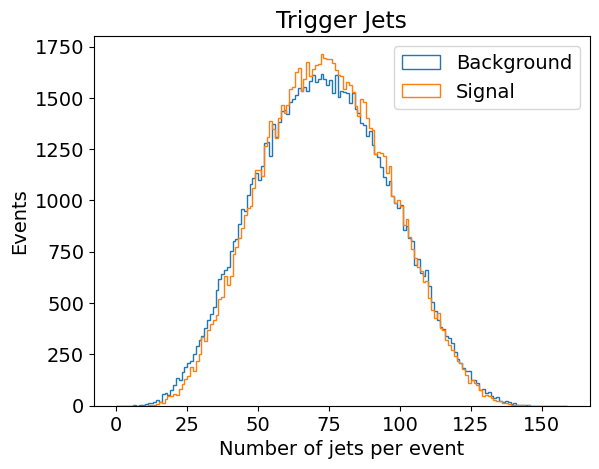

In [ ]:
# Plot jet multiplicity (trigger jets)
plt.hist(jet_number_trigger_bkg, bins=range(160), histtype='step', label='Background')
plt.hist(jet_number_trigger_sig, bins=range(160), histtype='step',label='Signal')
plt.xlabel('Number of jets per event')
plt.ylabel('Events')
plt.title('Trigger Jets')
plt.legend()
plt.show()

In [ ]:
# Compute total number of trigger jets
totalNjets_trigger_bkg = np.sum(jet_number_trigger_bkg)
totalNjets_trigger_sig = np.sum(jet_number_trigger_sig)
print(f'Total number of trigger jets in the background: {totalNjets_trigger_bkg}')
print(f'Total number of trigger jets in the signal: {totalNjets_trigger_sig}')

Total number of trigger jets in the background: 7273053
Total number of trigger jets in the signal: 7338728


## 2 - Jet Energy

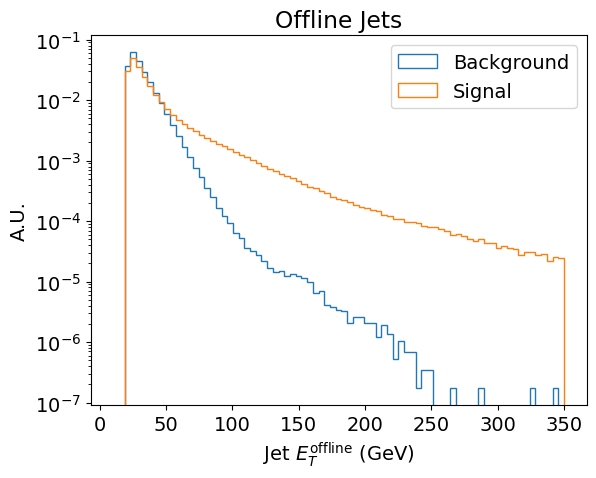

In [ ]:
# Plot jet pT (offline)
plt.hist(ak.flatten(background.pt), bins = np.linspace(10,350,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal.pt), bins = np.linspace(10,350,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Jet $E_{T}^{\mathrm{offline}}$ (GeV)')
plt.title('Offline Jets')
plt.ylabel('A.U.')
plt.yscale('log')
plt.legend()
plt.show()

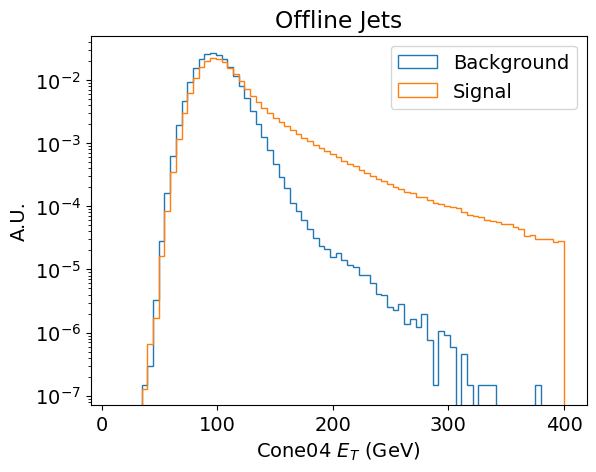

In [ ]:
# Plot jet pT (offline)
plt.hist(ak.flatten(background.ConeEnergy), bins = np.linspace(10,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal.ConeEnergy), bins = np.linspace(10,400,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Cone04 $E_T$ (GeV)')
plt.title('Offline Jets')
plt.ylabel('A.U.')
plt.yscale('log')
plt.legend()
plt.show()

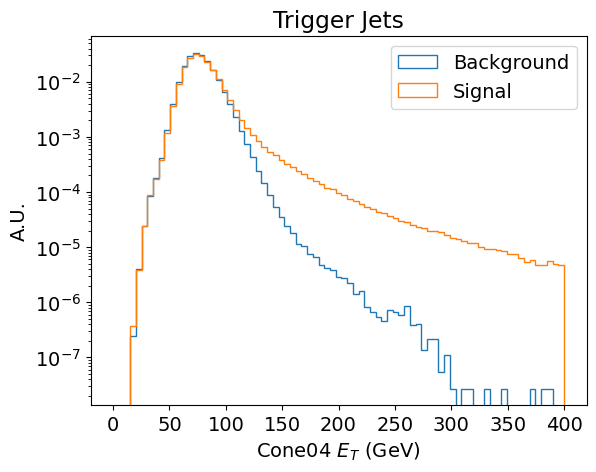

In [ ]:
# Plot jet pT (trigger)
plt.hist(ak.flatten(background_sw.pt), bins = np.linspace(0,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal_sw.pt), bins = np.linspace(0,400,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Cone04 $E_{T}$ (GeV)')
plt.ylabel('A.U.')
plt.xticks(np.arange(0, 430, 50))
plt.title('Trigger Jets')
plt.yscale('log')
plt.legend()
plt.show()

## 3 - Jet eta and phi

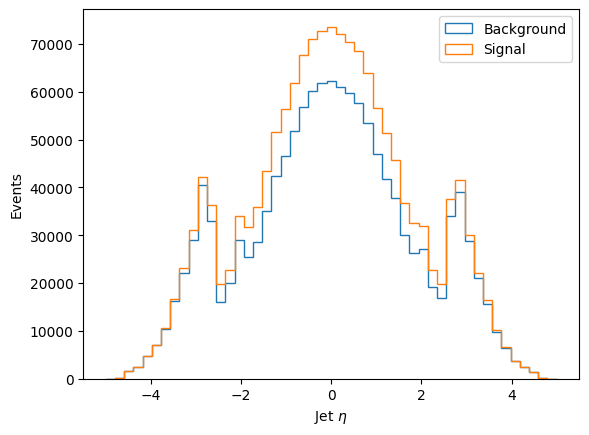

In [ ]:
# Plot offline jet eta
plt.hist(ak.flatten(background.eta), bins = np.linspace(-5,5,50), histtype='step', label='Background')
plt.hist(ak.flatten(signal.eta), bins = np.linspace(-5,5,50), histtype='step',label='Signal')
plt.xlabel(r'Jet $\eta$')
plt.ylabel('Events')
plt.legend()
plt.show()

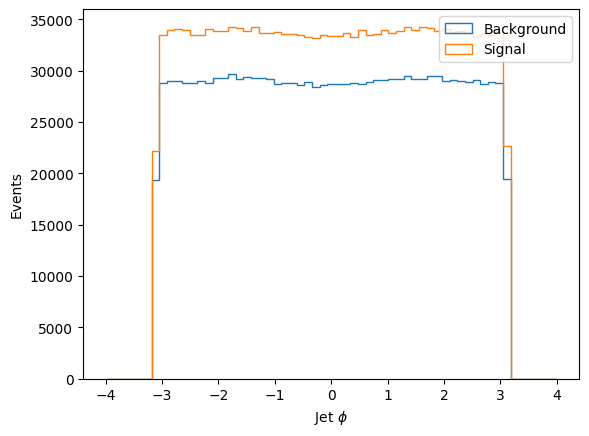

In [ ]:
# Plot offline jet phi
plt.hist(ak.flatten(background.phi), bins = np.linspace(-4,4,60), histtype='step', label='Background')
plt.hist(ak.flatten(signal.phi), bins = np.linspace(-4,4,60), histtype='step',label='Signal')
plt.xlabel(r'Jet $\phi$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

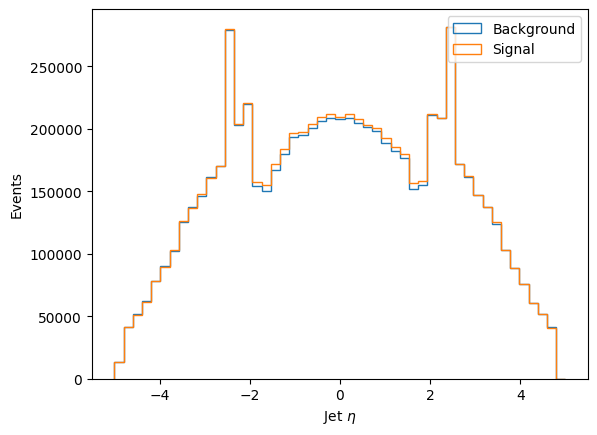

In [ ]:
# Plot trigger jet eta
plt.hist(ak.flatten(background_sw.eta), bins = np.linspace(-5,5,50), histtype='step', label='Background')
plt.hist(ak.flatten(signal_sw.eta), bins = np.linspace(-5,5,50), histtype='step',label='Signal')
plt.xlabel(r'Jet $\eta$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

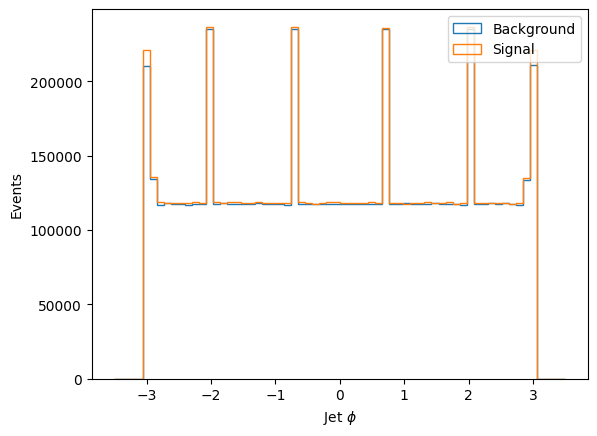

In [ ]:
# Plot trigger jet phi
plt.hist(ak.flatten(background_sw.phi), bins = np.linspace(-3.5,3.5,65), histtype='step', label='Background')
plt.hist(ak.flatten(signal_sw.phi), bins = np.linspace(-3.5,3.5,65), histtype='step',label='Signal')
plt.xlabel(r'Jet $\phi$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

## 4 - Invariant mass

In [ ]:
true_mass_bkg = np.load('true_mHH_bkg.npy')
true_mass_sig = np.load('true_mHH_sig.npy')

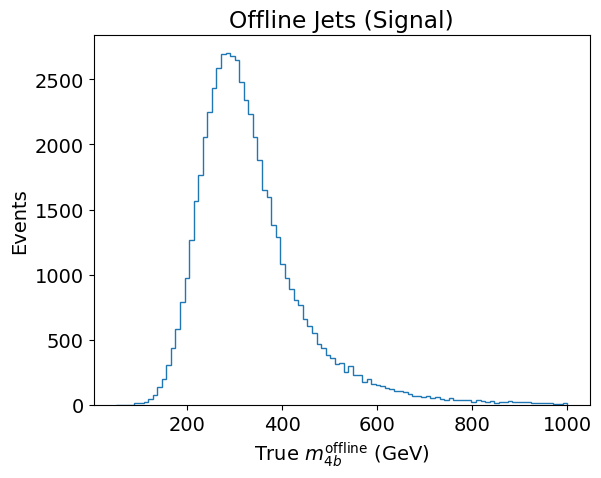

In [ ]:
# Plot invariant mass (offline) of the four leading jets
#plt.hist(true_mass_bkg, bins = np.linspace(50,1000,100), histtype='step', label='Background')
plt.hist(true_mass_sig, bins = np.linspace(50,1000,100), histtype='step')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.title('Offline Jets (Signal)')
plt.ylabel('Events')
plt.show()

## 5 - PU and HS offline jets

In [ ]:
# Background
# Select pile-up jets
bkg_pile_up = background[background.Pileup == 1]
bkg_pu_b_jets = bkg_pile_up[bkg_pile_up.Flavour == 5]

# Determine number of pile-up jets in each event
bkg_pile_up_number = []
for event in range(len(bkg_pu_b_jets)):
    pu_jets_number = len(bkg_pu_b_jets[event])
    bkg_pile_up_number.append(pu_jets_number)

# Select hard-scatter jets and determine the number in each event
bkg_hard_scatter = background[background.Pileup == 0]
bkg_hard_scatter_b_jets = bkg_hard_scatter[bkg_hard_scatter.Flavour == 5]
bkg_hard_scatter_number = []
for event in range(len(bkg_hard_scatter_b_jets)):
    hs_jets_number = len(bkg_hard_scatter_b_jets[event])
    bkg_hard_scatter_number.append(hs_jets_number)

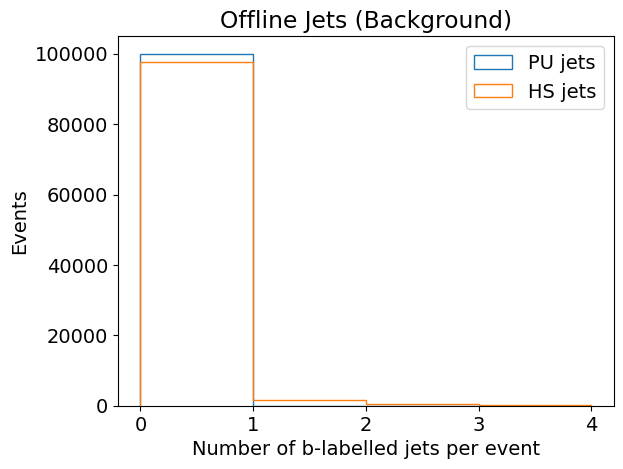

In [ ]:
# Plot histogram
binwidth = 1
plt.hist(bkg_pile_up_number, bins=range(5), histtype='step', label='PU jets')
plt.hist(bkg_hard_scatter_number, bins=range(5), histtype='step', label='HS jets')
plt.legend()
plt.title('Offline Jets (Background)')
plt.xlabel('Number of b-labelled jets per event')
plt.ylabel('Events')
plt.show()

In [ ]:
# Signal
# Select pile-up jets and determine number per event
sig_pile_up = signal[signal.Pileup == 1]
sig_pu_b_jets = sig_pile_up[sig_pile_up.Flavour == 5]
sig_pile_up_number = []
for event in range(len(sig_pu_b_jets)):
    pu_jets_number = len(sig_pu_b_jets[event])
    sig_pile_up_number.append(pu_jets_number)

# Select hard scatter jets and determine number per event
sig_hard_scatter = signal[signal.Pileup == 0]
sig_hard_scatter_b_jets = sig_hard_scatter[sig_hard_scatter.Flavour == 5]
sig_hard_scatter_number = []
for event in range(len(sig_hard_scatter_b_jets)):
    hs_jets_number = len(sig_hard_scatter_b_jets[event])
    sig_hard_scatter_number.append(hs_jets_number)

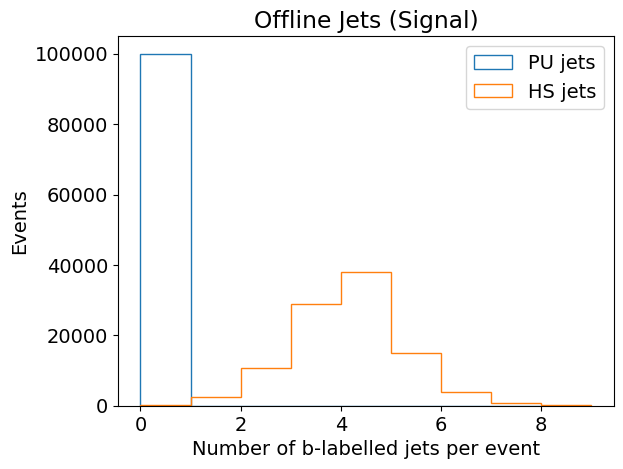

In [ ]:
# Plot histogram
binwidth = 1
plt.hist(sig_pile_up_number, bins=range(10), histtype='step', label='PU jets')
plt.hist(sig_hard_scatter_number, bins=range(10), histtype='step', label='HS jets')
plt.legend()
plt.title('Offline Jets (Signal)')
plt.xlabel('Number of b-labelled jets per event')
plt.ylabel('Events')
plt.show()

## 6 - Trigger Matched Jets

In [ ]:
# Retrieve jets matched with offline jets
bkg_match = background_sw[background_sw.isMatched == 1]
sig_match = signal_sw[signal_sw.isMatched == 1]

# Determine number of matched jets in each event
bkg_match_number = []
for event in range(len(bkg_match)):
  matched_jets_number = len(bkg_match[event])
  bkg_match_number.append(matched_jets_number)

sig_match_number = []
for event in range(len(sig_match)):
  matched_jets_number = len(sig_match[event])
  sig_match_number.append(matched_jets_number)

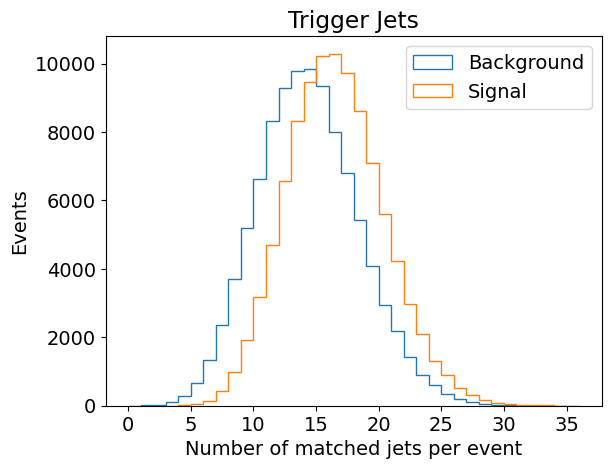

In [ ]:
# Plot histogram
binwidth = 1
plt.hist(bkg_match_number, bins=range(min(bkg_match_number), max(bkg_match_number) + binwidth, binwidth), histtype='step', label='Background')
plt.hist(sig_match_number, bins=range(min(sig_match_number), max(sig_match_number) + binwidth, binwidth), histtype='step', label='Signal')
plt.legend()
plt.title('Trigger Jets')
plt.xlabel('Number of matched jets per event')
plt.ylabel('Events')
plt.show()

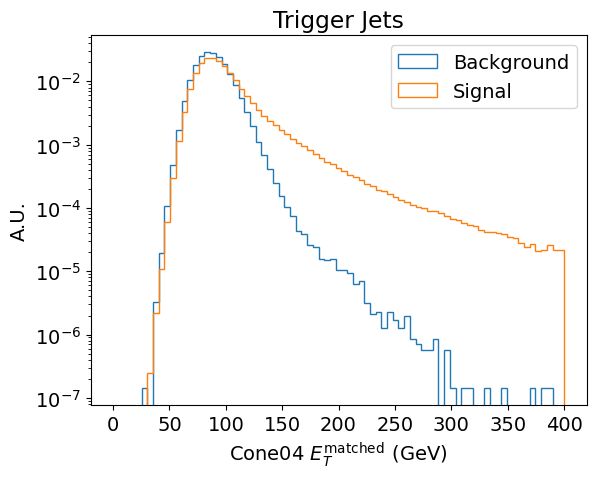

In [ ]:
# Plot histogram of the jets pT
plt.hist(ak.flatten(bkg_match.pt), bins=np.linspace(0,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(sig_match.pt), bins=np.linspace(0,400,80), histtype='step', label='Signal', density=True)
plt.legend()
plt.title('Trigger Jets')
plt.xlabel(r'Cone04 $E_{T}^{\mathrm{matched}} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('A.U.')
plt.yscale('log')
plt.xticks(np.arange(0, 430, 50))
plt.show()

# V - Compute EFPs

In [8]:
# Define some parameters of the EFPs
dmax = 6
measure = 'hadr'
beta = 1
test_frac = 0.2
colors = ['tab:red', 'tab:orange', 'tab:olive', 'tab:green', 'tab:blue', 'tab:purple']

# Define set of graphs
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)

## 1 - Offline Jets

In [15]:
# Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
bkg_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in background
]

sig_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in signal
]

data_efp = bkg_data_pfn + sig_data_pfn

In [ ]:
# Calculate all EFPs with d<=dmax
print('Calculating d <= {} EFPs'.format(dmax), end='')
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)
X_EFP = efpset.batch_compute(data_efp)
print('Done')

# Save results
np.save('efps_d6_Apr26.npy', X_EFP)

Calculating d <= 6 EFPsDone


In [16]:
# Retrieve energy of the fourth leading jet
data = ak.concatenate([background_ordered, signal_ordered])
pt_fourth_leading_jet = []
for event in data:
  if len(event) < 4:
    pt_fourth_leading_jet.append(0)
  else:
    jet_4 = event[3]
    pt_4 = jet_4[0]
    pt_fourth_leading_jet.append(pt_4)
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/pt4_offline.npy', pt_fourth_leading_jet)

## 2 - Trigger Jets

In [10]:
# Retrieve jets matched with offline jets
bkg_match = background_sw[background_sw.isMatched == 1]
sig_match = signal_sw[signal_sw.isMatched == 1]

data_sw = ak.concatenate([bkg_match, sig_match])

In [11]:
# Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
bkg_efp_sw = []
for event in bkg_match:
  event = sorted(event, key=lambda j: j.pt, reverse=True)
  event_data = [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
  bkg_efp_sw.append(event_data)

sig_efp_sw = []
for event in sig_match:
  event = sorted(event, key=lambda j: j.pt, reverse=True)
  event_data = [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
  sig_efp_sw.append(event_data)

In [18]:
data_pfn_all = bkg_efp_sw + sig_efp_sw

# Remove events with no matched jet (and remove corresponding pt4 offline and mass)
pt4_offline_all = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/pt4_offline.npy')
true_mass_bkg = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_bkg.npy')
true_mass_sig = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_sig.npy')
true_mass_offline_all = np.concatenate([true_mass_bkg, true_mass_sig])

data_pfn = []
pt4_offline = []
true_mass_offline = []

for i in range(len(data_pfn_all)):
  if len(data_pfn_all[i]) != 0:
    data_pfn.append(data_pfn_all[i])
    pt4_offline.append(pt4_offline_all[i])
    true_mass_offline.append(true_mass_offline_all[i])

pt4_offline = np.array(pt4_offline)
true_mass_offline = np.array(true_mass_offline)
#data_pfn = np.array(data_pfn)

In [67]:
pt_fourth_leading_jet = []
for event in data_pfn:
  if len(event) < 4:
    pt_fourth_leading_jet.append(0)
  else:
    jet_4 = event[3]
    pt_4 = jet_4[0]
    pt_fourth_leading_jet.append(pt_4)

In [21]:
# Remove events with no matched jets
bkg_efp_sw = [event for event in bkg_efp_sw if event]
sig_efp_sw = [event for event in sig_efp_sw if event]

# Create arrays with the labels
bkg_labels = np.zeros(len(bkg_efp_sw))
sig_labels = np.ones(len(sig_efp_sw))

# Combine jet data and labels
y = np.concatenate([bkg_labels, sig_labels])

In [22]:
# Calculate all EFPs with d<=dmax
print('Calculating d <= {} EFPs'.format(dmax), end='')
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)
X_EFP = efpset.batch_compute(data_pfn)
print('Done')

# Save results
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/EFPs/L1Trigger_jets.npy', X_EFP)

Calculating d <= 6 EFPsDone


# VI - Load data

In [17]:
# Define some parameters of the EFPs
dmax = 6
measure = 'hadr'
beta = 1
test_frac = 0.2
colors = ['tab:red', 'tab:orange', 'tab:olive', 'tab:green', 'tab:blue', 'tab:purple']

# Define set of graphs
efpset = ef.EFPSet(('d<=', dmax), measure=measure,  beta=beta)

In [18]:
# Load data with EFPs
X_EFP = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/EFPs/offline_jets.npy')

In [16]:
# Create arrays with the labels
bkg_labels = np.zeros(len(background))
sig_labels = np.ones(len(signal))
y = np.concatenate([bkg_labels, sig_labels])

In [17]:
# Load data with fourth leading jet pt and true 4b mass
pt4_offline = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/pt4_offline.npy')

true_mass_bkg = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_bkg.npy')
true_mass_sig = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/true_mHH_sig.npy')
true_mass = np.concatenate([true_mass_bkg, true_mass_sig])

# VII - Define functions

In [18]:
"""
plot_scores: plots the output scores distribution for signal and background.
The function takes as input two arrays, corresponding to the background and
signal scores and plots them in a histogram.
"""
def plot_scores(preds_bkg, preds_sig):
  plt.hist(preds_bkg, bins=np.linspace(0,1,200), histtype='step', label='Background')
  plt.hist(preds_sig, bins=np.linspace(0,1,200), histtype='step',label='Signal')
  plt.xlabel('Classifier Output')
  plt.ylabel('Events')
  plt.legend()
  plt.show()

In [93]:
"""
get_threshold: calculates the 5% background acceptance threshold.
The function takes as input the background scores and returns the threshold
that gives a background acceptance of 0.05.
"""
def get_threshold(preds_bkg):
  # Define histogram for bkg scores
  bins = np.linspace(0,1,1000)
  counts, edges = np.histogram(preds_bkg, bins = bins)
  # Calculate histogram integral
  total_integral = np.sum(counts)
  # Calculate the bkg efficiency for each threshold
  thresholds = []
  background_efficiency = []
  bkg_counts = 0
  for i in range(len(counts)):
    bkg_counts += counts[i]
    if total_integral != 0:
      bkg_acceptance = bkg_counts/total_integral
      background_efficiency.append(bkg_acceptance)
      cut = edges[i+1]
      thresholds.append(cut)
      if bkg_acceptance >= 0.95:
        return(cut)

In [23]:
"""
signal_energies: retrieves the energy of the fourth leading jet for all signal events.
The function takes as input the test set and returns an array with the energy of the
fourth leading jet for the signal events.
"""
def signal_energies(X_test, y_test, pt4_test):
  signal_energies = []
  for i in range(len(X_test)):
    if y_test[i] == 1:
      if pt4_test[i] != 0:
        signal_energies.append(pt4_test[i])
  return signal_energies

"""
selected_energies: retrieves the energy of the fourth leading jet for all selected signal events.
The function takes as input the array with the predictions, the threshold and
labels and energy of the test set and returns an array with the energy of the
fourth leading jet for the selected signal events.
"""
def selected_energies(preds, y_test, pt4_test, cut):
  selected_energies = []
  for i in range(len(preds)):
    if preds[i] >= cut and y_test[i] == 1:
      selected_energies.append(pt4_test[i])
  return selected_energies

In [25]:
"""
get_EFP: retrieves the EFP with index i in a efpset.
The function takes as input the efpset and the index of the EFP and returns the
number of vertices and edges (respectively) of the corresponding graph.
"""
def get_EFP(efpset, i):
  i = int(i)
  graph = efpset.graphs(i)
  n, _, d, v, _, c, p, _ = efpset.specs[i]
  return n, d

In [26]:
"""
is_EFP_prime: check if the EFP with index i is prime in a efpset.
The function takes as input the efpset and the index of the EFP and returns 1 if
the EFP is prime and p > 1 otherwise, with p corresponding to the number of prime EFPs
that compose the given EFP.
"""
def is_EFP_prime(efpset, i):
  i = int(i)
  graph = efpset.graphs(i)
  n, _, d, v, _, c, p, _ = efpset.specs[i]
  return p

# VIII - Selection with EFPs

In this section, we apply a cut directly on the EFPs to distinguish signal and background.

## 1 - Correlation Plots

In [ ]:
# Compute correlation between some EFPs (example)
efpset = ef.EFPSet(('d<=', 6), measure=measure, beta=beta)
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
EFPs_bkg = []
columns_bkg = []
EFPs_sig = []
columns_sig = []
index = [1,146,6,112,13,66,15,29,146,157,65]
for i in index:
  i = int(i)
  EFP_bkg = X_EFP[bkg_idx,i]
  EFP_sig = X_EFP[signal_idx,i]
  n, d = get_EFP(efpset, i)
  EFPs_bkg.append(EFP_bkg)
  EFPs_sig.append(EFP_sig)
  columns_bkg.append("EFP {}: n = {}, d = {}".format(i, n, d))
  columns_sig.append("EFP {}: n = {}, d = {}".format(i, n, d))

# create pandas DF with transpose EFPs
df_EFPs_bkg = pd.DataFrame(EFPs_bkg)
df_EFPs_bkg = df_EFPs_bkg.transpose()
df_EFPs_bkg.columns = columns_bkg
df_EFPs_sig = pd.DataFrame(EFPs_sig)
df_EFPs_sig = df_EFPs_sig.transpose()
df_EFPs_sig.columns = columns_sig

In [ ]:
corr_matrix_bkg = df_EFPs_bkg.corr()
corr_matrix_bkg

,"EFP 1: n = 2, d = 1","EFP 146: n = 7, d = 6","EFP 6: n = 2, d = 6","EFP 112: n = 6, d = 6","EFP 13: n = 3, d = 6","EFP 66: n = 5, d = 6","EFP 15: n = 3, d = 6","EFP 29: n = 4, d = 6","EFP 146: n = 7, d = 6","EFP 157: n = 4, d = 2","EFP 65: n = 5, d = 6"
"EFP 1: n = 2, d = 1",1.000000,0.852007,0.857217,0.862585,0.868800,0.868882,0.870242,0.870858,0.852007,0.996000,0.871555
"EFP 146: n = 7, d = 6",0.852007,1.000000,0.969675,0.998156,0.974297,0.992743,0.970371,0.983925,1.000000,0.871115,0.991739
"EFP 6: n = 2, d = 6",0.857217,0.969675,1.000000,0.981657,0.999252,0.989923,0.997289,0.994515,0.969675,0.883783,0.991539
"EFP 112: n = 6, d = 6",0.862585,0.998156,0.981657,1.000000,0.985617,0.998204,0.983123,0.992900,0.998156,0.883674,0.997632
"EFP 13: n = 3, d = 6",0.868800,0.974297,0.999252,0.985617,1.000000,0.993140,0.998512,0.996906,0.974297,0.895012,0.994653
"EFP 66: n = 5, d = 6",0.868882,0.992743,0.989923,0.998204,0.993140,1.000000,0.992209,0.998233,0.992743,0.891853,0.999791
"EFP 15: n = 3, d = 6",0.870242,0.970371,0.997289,0.983123,0.998512,0.992209,1.000000,0.997671,0.970371,0.897111,0.993095
"EFP 29: n = 4, d = 6",0.870858,0.983925,0.994515,0.992900,0.996906,0.998233,0.997671,1.000000,0.983925,0.895586,0.998306
"EFP 146: n = 7, d = 6",0.852007,1.000000,0.969675,0.998156,0.974297,0.992743,0.970371,0.983925,1.000000,0.871115,0.991739
"EFP 157: n = 4, d = 2",0.996000,0.871115,0.883783,0.883674,0.895012,0.891853,0.897111,0.895586,0.871115,1.000000,0.894878


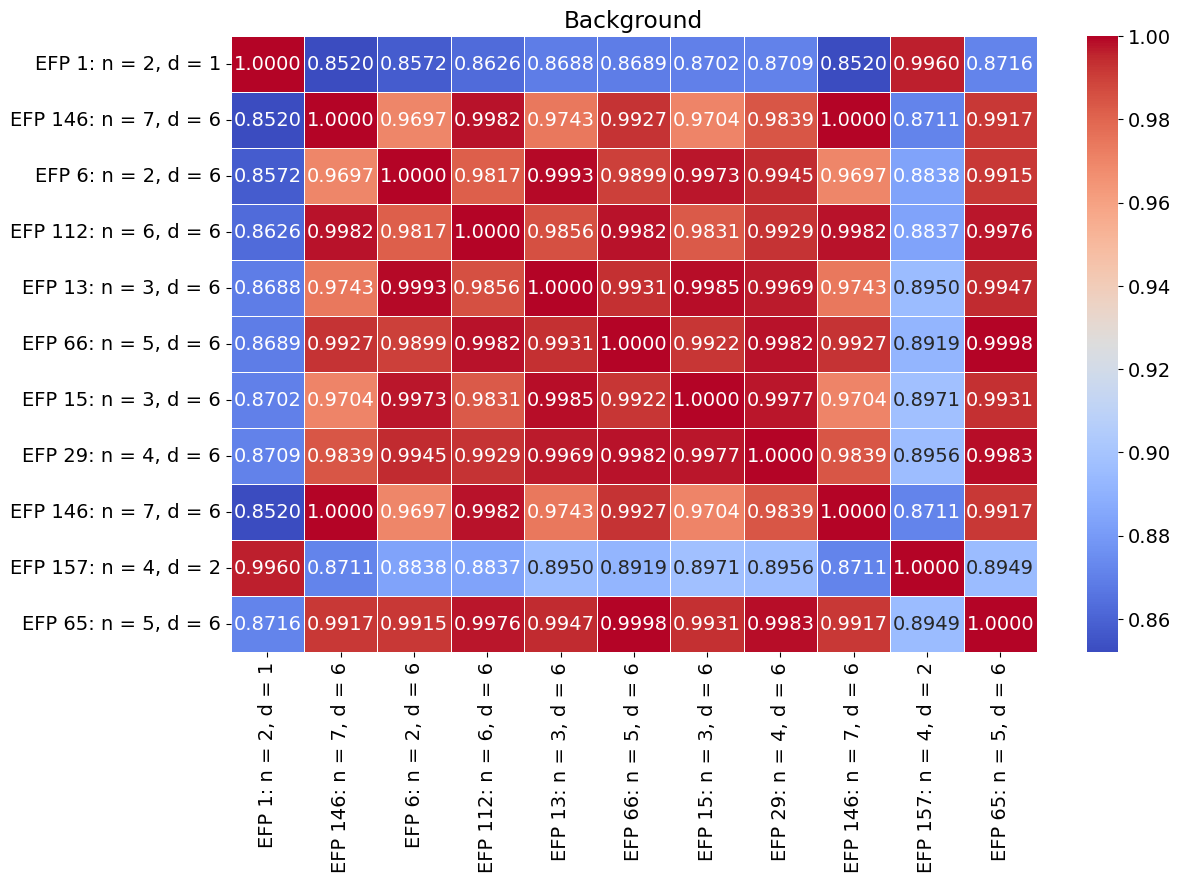

In [ ]:
# Plot correlation matrix (background)
import seaborn as sns
plt.figure(figsize=(13,8))
sns.heatmap(corr_matrix_bkg, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Background")
plt.show()

In [ ]:
corr_matrix_sig = df_EFPs_sig.corr()
corr_matrix_sig

,"EFP 1: n = 2, d = 1","EFP 146: n = 7, d = 6","EFP 6: n = 2, d = 6","EFP 112: n = 6, d = 6","EFP 13: n = 3, d = 6","EFP 66: n = 5, d = 6","EFP 15: n = 3, d = 6","EFP 29: n = 4, d = 6","EFP 146: n = 7, d = 6","EFP 157: n = 4, d = 2","EFP 65: n = 5, d = 6"
"EFP 1: n = 2, d = 1",1.000000,0.828575,0.867750,0.846983,0.877015,0.860546,0.876738,0.869129,0.828575,0.997020,0.865730
"EFP 146: n = 7, d = 6",0.828575,1.000000,0.964801,0.998078,0.968102,0.992508,0.967363,0.983591,1.000000,0.841273,0.990470
"EFP 6: n = 2, d = 6",0.867750,0.964801,1.000000,0.978314,0.999440,0.987816,0.997317,0.993403,0.964801,0.888667,0.990575
"EFP 112: n = 6, d = 6",0.846983,0.998078,0.978314,1.000000,0.981257,0.998162,0.981083,0.992817,0.998078,0.861670,0.997048
"EFP 13: n = 3, d = 6",0.877015,0.968102,0.999440,0.981257,1.000000,0.990336,0.998467,0.995431,0.968102,0.897478,0.992939
"EFP 66: n = 5, d = 6",0.860546,0.992508,0.987816,0.998162,0.990336,1.000000,0.990926,0.998229,0.992508,0.877181,0.999714
"EFP 15: n = 3, d = 6",0.876738,0.967363,0.997317,0.981083,0.998467,0.990926,1.000000,0.997005,0.967363,0.897738,0.992737
"EFP 29: n = 4, d = 6",0.869129,0.983591,0.993403,0.992817,0.995431,0.998229,0.997005,1.000000,0.983591,0.887652,0.998655
"EFP 146: n = 7, d = 6",0.828575,1.000000,0.964801,0.998078,0.968102,0.992508,0.967363,0.983591,1.000000,0.841273,0.990470
"EFP 157: n = 4, d = 2",0.997020,0.841273,0.888667,0.861670,0.897478,0.877181,0.897738,0.887652,0.841273,1.000000,0.882803


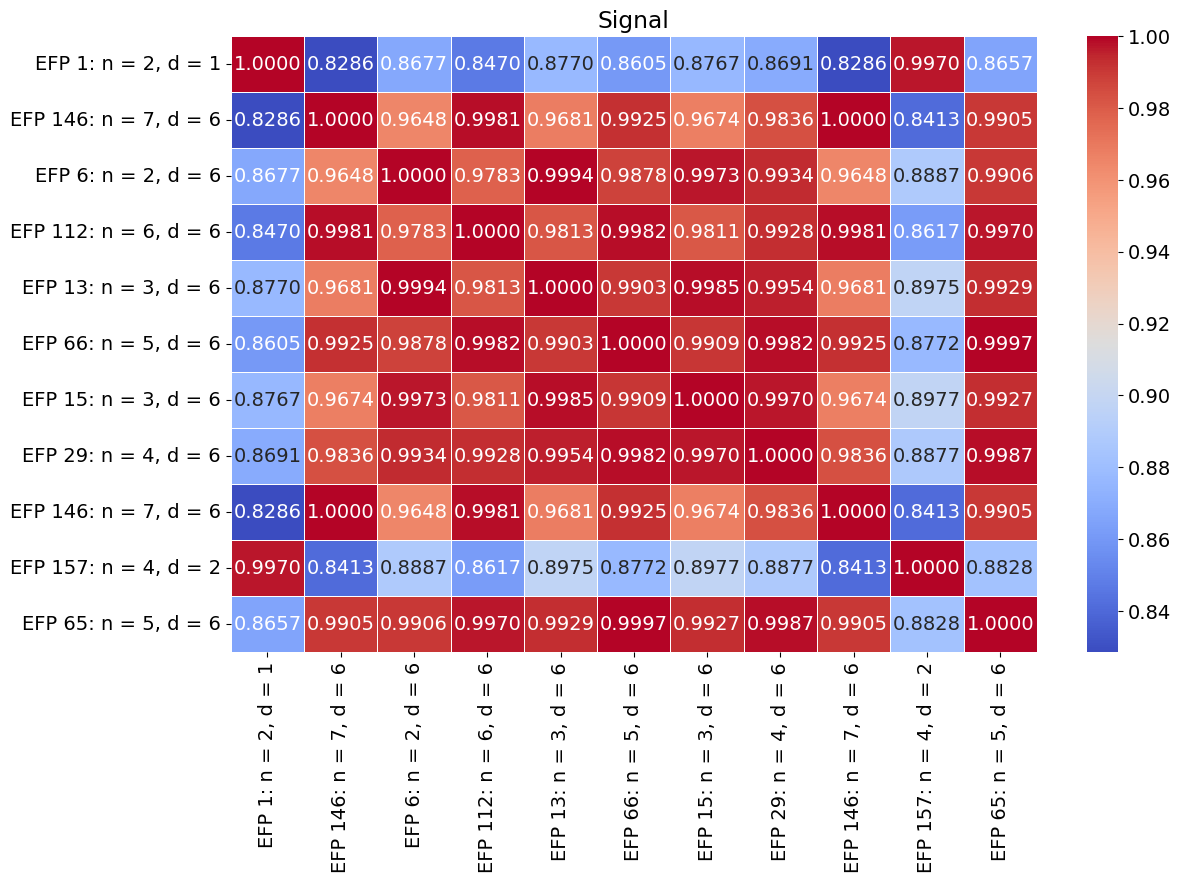

In [ ]:
# Plot correlation matrix (signal)
plt.figure(figsize=(13,8))
sns.heatmap(corr_matrix_sig, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Signal")
plt.show()

## 2 - ROC Curve

In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
aucs = []

for i in range(X_EFP.shape[1]):
  EFP_bkg = X_EFP[bkg_idx,i]
  EFP_sig = X_EFP[signal_idx,i]
  scores = np.concatenate([EFP_bkg, EFP_sig])
  roc = roc_curve(y, scores)
  auc = roc_auc_score(y, scores)
  aucs.append(auc)

# Print five max values of auc and select corresponding EFP
max_aucs = np.sort(aucs)[-5:]
print(max_aucs)
max_efps = np.argsort(aucs)[-5:]
print(max_efps)

[0.38959651 0.3915933  0.398262   0.40805098 0.49918414]
[ 66 111 112 146   0]


In [ ]:
aucs = np.sort(aucs)[::-1]
print(aucs)

[0.49918414 0.40805098 0.398262   0.3915933  0.38959651 0.38837569
 0.38797988 0.38468692 0.38429746 0.38285945 0.38284226 0.38271329
 0.38213873 0.38130334 0.3807419  0.38038889 0.37993859 0.3793886
 0.37933783 0.37877004 0.37835953 0.37829899 0.3779881  0.37763262
 0.37753711 0.37715263 0.37711761 0.37707309 0.37700582 0.37696295
 0.37689325 0.37644126 0.37624719 0.37614054 0.37566657 0.37542988
 0.37469997 0.37461236 0.37432397 0.3741917  0.3740553  0.37396583
 0.37387507 0.37368704 0.37368242 0.37366627 0.3734359  0.37336223
 0.37313944 0.37300868 0.37292603 0.37272531 0.37254181 0.37236838
 0.37220775 0.37214672 0.37199423 0.37195695 0.37185317 0.3717946
 0.37178041 0.37147261 0.3712752  0.37125211 0.37110383 0.37107696
 0.37101271 0.37096775 0.3709661  0.37085897 0.37076002 0.37075307
 0.37037406 0.37034672 0.37013972 0.37011082 0.37007913 0.37001172
 0.36984012 0.36971444 0.36969434 0.369594   0.36942149 0.36928044
 0.36926902 0.36924542 0.36923512 0.36922958 0.36896828 0.368673

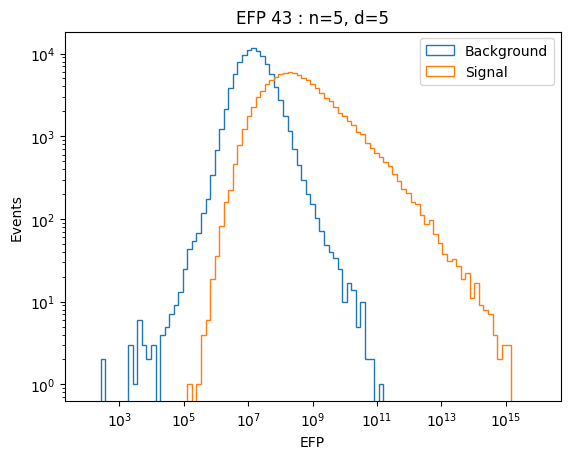

In [ ]:
# Plot histogram of one EFP (example)
i = 43
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
plt.hist(EFP_bkg, bins=np.logspace(2,16,100), histtype='step', label='Background')
plt.hist(EFP_sig, bins=np.logspace(2,16,100), histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

# IX - Linear Classifier

In this section, we apply a linear classifier (Linear Discriminant Analysis) to distinguish signal and background using supervised learning.

## 1 - Test different dmax


EFPs d <= 1 AUC: 0.5677448658425852


EFPs d <= 2 AUC: 0.6802274200882302


EFPs d <= 3 AUC: 0.7162511556066563


EFPs d <= 4 AUC: 0.7676011076137208


EFPs d <= 5 AUC: 0.8033534636431972


EFPs d <= 6 AUC: 0.8381798627194508



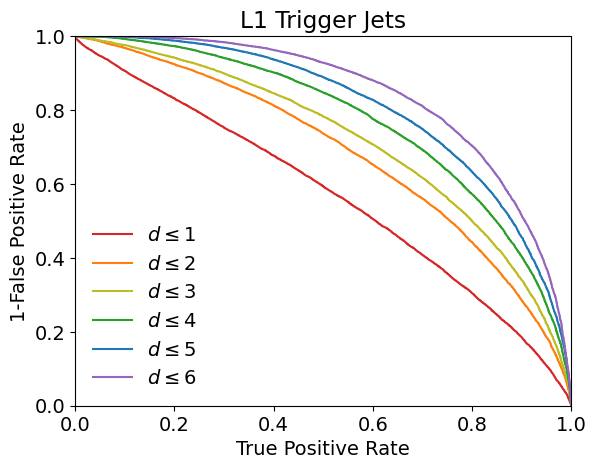

In [29]:
# Train models with different numbers of EFPs as input
dmax = 6
rocs = []
aucs = []
for d in range(1, dmax+1):

    # build architecture
    model =LinearDiscriminantAnalysis(tol=1e-12)

    # select EFPs with degree <= d
    X_d = X_EFP[:,efpset.sel(('d<=', d))]

    # Split into training and test sets
    (X_train, X_test, y_train, y_test) = train_test_split(X_d, y, test_size=test_frac)

    # Standardize data
    scaler = StandardScaler()
    X_train_nor = scaler.fit_transform(X_train)
    X_test_nor = scaler.transform(X_test)

    # train model
    model.fit(X_train_nor, y_train)

    # get predictions on test data
    preds = model.predict_proba(X_test_nor)

    # get ROC curve if we have sklearn
    if roc_curve:
        rocs.append(roc_curve(y_test, preds[:,1]))

        # get area under the ROC curve
        auc = roc_auc_score(y_test, preds[:,1])
        aucs.append(auc)
        print()
        print('EFPs d <= {} AUC:'.format(d), auc)
        print()

# iterate over the ROC curves and plot them
for i,d in enumerate(range(1, dmax+1)):
    plt.plot(rocs[i][1], 1-rocs[i][0], '-', color=colors[i],
                                            label=r'$d \leq${}'.format(d))

# axes labels
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.title('L1 Trigger Jets')
# axes limits
plt.xlim(0, 1)
plt.ylim(0, 1)

# make legend and show plot
plt.legend(loc='lower left', frameon=False)
plt.savefig('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_ROC_vs_d.png', bbox_inches='tight')
plt.show()

## 2 - Turn-on Curve

In this section, the inputs of the classifier are all the EFPs with d<=6 (205 EFPs per event).

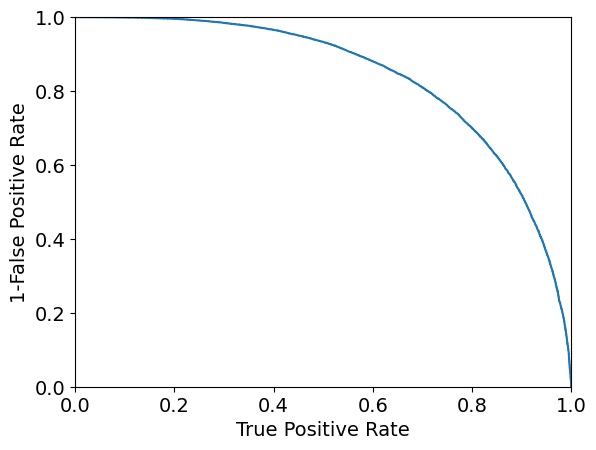


AUC: 0.8386101225



In [31]:
# Define model
linear_model = LinearDiscriminantAnalysis(tol=1e-12)

# Split into training and test sets
test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test, pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_EFP[signal_idx], pt4_offline[signal_idx], true_mass_offline[signal_idx], y[signal_idx], test_size=test_frac, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test,  mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_EFP[bkg_idx], pt4_offline[bkg_idx], true_mass_offline[bkg_idx], y[bkg_idx], test_size=test_frac, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

# Standardize data
scaler = StandardScaler()
X_train_nor = scaler.fit_transform(X_train)
X_test_nor = scaler.transform(X_test)

# Train model
linear_model.fit(X_train_nor, y_train)

# Get predictions on the test set
preds = linear_model.predict_proba(X_test_nor)

# Plot ROC curve
roc = roc_curve(y_test, preds[:,1])
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y_test, preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [32]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = preds[y_test == 0][:,1]
preds_sig = preds[y_test == 1][:,1]

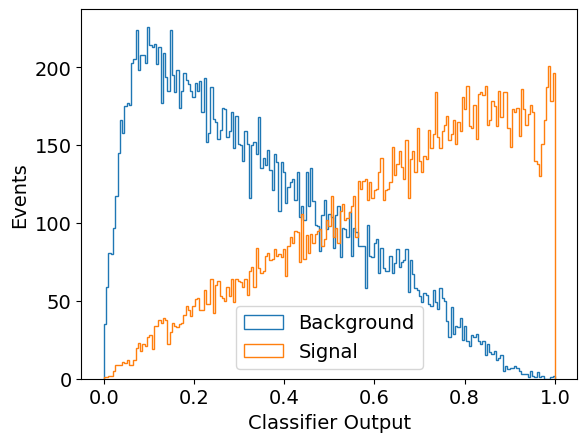

In [33]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [34]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.7307


### Energy of the fourth-leading jet

In [35]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
selected_energies = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if pt4_test[i] != 0:
      signal_energies.append(pt4_test[i])
      if preds[i][1] >= cut:
        selected_energies.append(pt4_test[i])

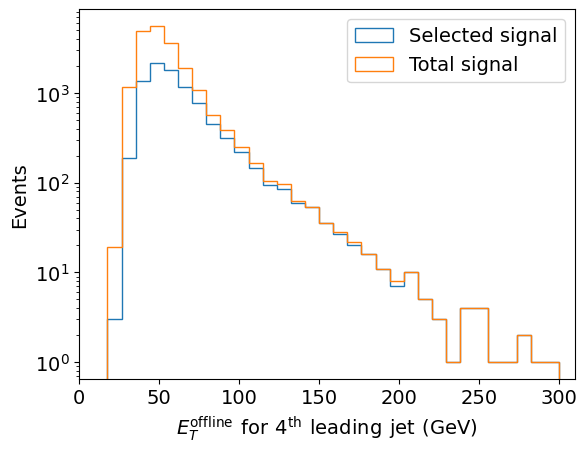

In [36]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_EFPdmax6_SignalEnergies.png", bbox_inches='tight')
plt.show()

In [37]:
bins=np.linspace(0.1,300,35)
selected_counts_lda, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_lda = []
energy_lda = []
sel_sig_counts_lda = []
sig_counts_lda = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts_lda)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts_lda[i]
  if sig_i != 0:
    sig_counts_lda.append(sig_i)
    sel_sig_counts_lda.append(sel_sig_i)
    signal_efficiency_lda.append(sel_sig_i/sig_i)
    energy_lda.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_lda, ci_upp_lda = proportion_confint(sel_sig_counts_lda, sig_counts_lda, alpha=0.05, method='beta')
# Compute error bars
err_low_lda = signal_efficiency_lda - ci_low_lda
err_upp_lda = ci_upp_lda - signal_efficiency_lda

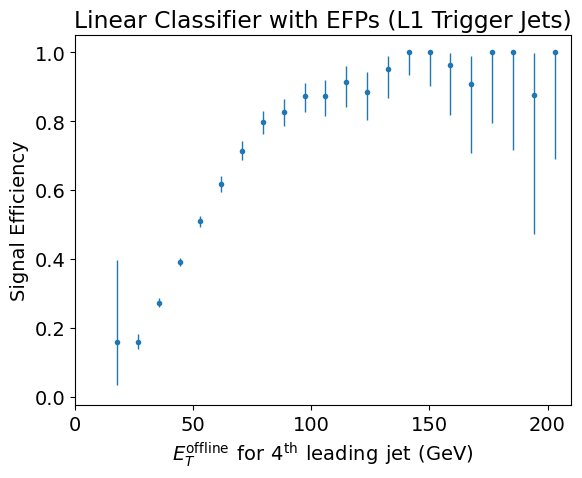

In [40]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_lda, signal_efficiency_lda, yerr=[err_low_lda, err_upp_lda], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.title('Linear Classifier with EFPs (L1 Trigger Jets)')
plt.xlim(0,210)
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/l1TriggerJets_EFPdmax6_TurnOn.png", bbox_inches='tight')
plt.show()

In [41]:
# Save results to plot later
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_lda_pt4.npz', energy=energy_lda, signal_eff=signal_efficiency_lda, err_low=err_low_lda, err_upp=err_upp_lda)
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_signal_energies.npy', signal_energies)


### Invariant mass of the bbbb system

In [42]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut:
        selected_mass.append(mass_test[i])

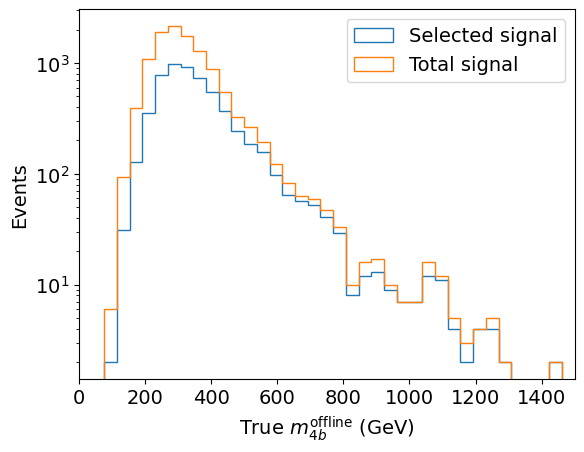

In [44]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='Selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='Total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_EFPdmax6_SignalMass.png", bbox_inches='tight')
plt.show()

In [45]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency


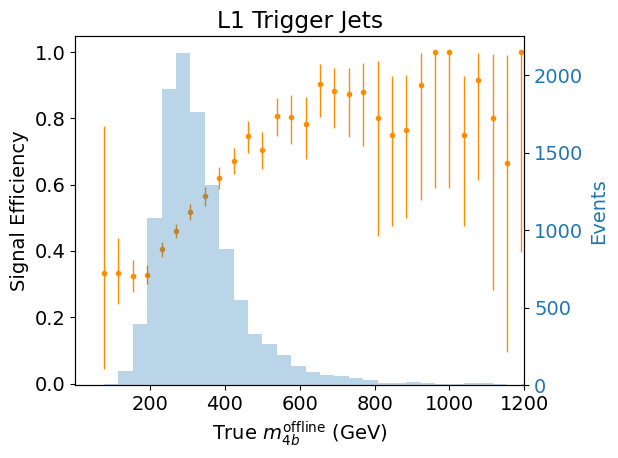

In [46]:
# Test adding invariant mass distribution in the background
fig, ax1 = plt.subplots()

ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1, color='darkorange')

ax2 = ax1.twinx()
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.set_xlim(0.1,1200)
ax1.set_title('L1 Trigger Jets')
fig.tight_layout()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1triggerJets_EFPdmax6_TurnOn_mass.png")
plt.show()

In [47]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_lda_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)
np.save('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_signal_mass.npy', signal_mass)

# X - PFN

In this section, we apply Particle Flow Networks (PFN) to distinguish signal and background using supervised learning.

In [19]:
# Convert labels to categorical
# bkg (1,0) and sig (0,1)
y_categorical = to_categorical(y, num_classes=2)

In [ ]:
# Apply padding with all-zero particles such that all events have the same
# number of jets
X_padded = pad_sequences(data_efp, padding='post', dtype='float32', value=0.0)

# Train-test split
test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test,  pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_padded[signal_idx], pt4_offline[signal_idx], true_mass[signal_idx], y_categorical[signal_idx], test_size=0.2, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test, mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_padded[bkg_idx], pt4_offline[bkg_idx], true_mass[bkg_idx], y_categorical[bkg_idx], test_size=0.2, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

In [ ]:
# Define masking layer to ensure all zero jets are not considered
# More information here: https://keras.io/api/layers/core_layers/masking/
masking_layer = tf.keras.layers.Masking(mask_value=0.0)

# Apply masking
masked_X_train = masking_layer(X_train)
masked_X_test = masking_layer(X_test)

# Access mask arrays
X_train_mask = masked_X_train._keras_mask
X_test_mask = masked_X_test._keras_mask

# Compute mean and std of the three features (pT, eta, phi) for the training set
# with numpy masked arrays
pt_train = np.ma.masked_array(X_train[:,:,0], mask=~X_train_mask)
eta_train = np.ma.masked_array(X_train[:,:,1], mask=~X_train_mask)
phi_train = np.ma.masked_array(X_train[:,:,2], mask=~X_train_mask)

mean_array = np.array([pt_train.mean(), eta_train.mean(), phi_train.mean()])
std_array = np.array([pt_train.std(), eta_train.std(), phi_train.std()])

# Define and apply normalization layer 
# More information here: https://keras.io/api/layers/preprocessing_layers/numerical/normalization/ 
scaler_layer = layers.Normalization(mean=mean_array, variance=std_array**2)

# Apply normalization
X_train_norm = scaler_layer(masked_X_train)
X_test_norm = scaler_layer(masked_X_test)

X_train_norm = masking_layer(tf.where(X_train_mask[..., tf.newaxis], X_train_norm, tf.zeros_like(X_train_norm)))
X_test_norm = masking_layer(tf.where(X_test_mask[..., tf.newaxis], X_test_norm, tf.zeros_like(X_test_norm)))

In [41]:
# PFN network architecture parameters
Phi_sizes, F_sizes = (100, 100, 100), (100, 100, 100)

# PFN network training parameters
num_epoch = 15
batch_size = 512

In [78]:
# build architecture
pfn = PFN(input_dim=X_train.shape[-1], Phi_sizes=Phi_sizes, F_sizes=F_sizes)

# train model
pfn.fit(X_train_norm, y_train,
        epochs=num_epoch,
        batch_size=batch_size,
        verbose=1)

# get predictions on test data
preds = pfn.predict(X_test_norm)

# get ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])

# get area under the ROC curve
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('PFN AUC:', auc)
print()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, None, 3)]            0         []                            
                                                                                                  
 tdist_0 (TimeDistributed)   (None, None, 100)            400       ['input[0][0]']               
                                                                                                  
 activation_7 (Activation)   (None, None, 100)            0         ['tdist_0[0][0]']             
                                                                                                  
 tdist_1 (TimeDistributed)   (None, None, 100)            10100     ['activation_7[0][0]']        
                                                                                            

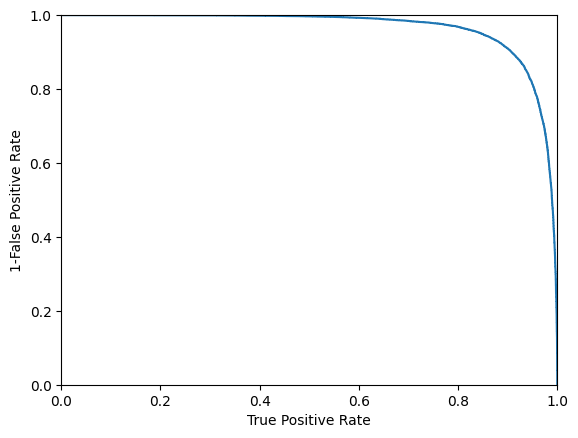


AUC: 0.9651371900000001



In [94]:
# Plot ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])
plt.plot(pfn_tp, 1-pfn_fp, '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.savefig('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_ROC.png', bbox_inches='tight')
plt.show()

# Print AUC
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [95]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = []
preds_sig = []
for i in range(len(y_test)):
  if y_test[i][1] == 0:
    preds_bkg.append(preds[i][1])
  if y_test[i][1] == 1:
    preds_sig.append(preds[i][1])

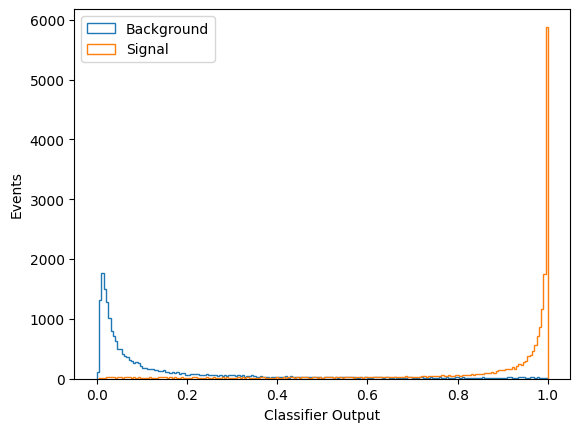

In [96]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [56]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.7227


## Energy of the fourth-leading jet

In [57]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
for i in range(len(X_test_norm)):
  if y_test[i][1] == 1:
    signal_energies.append(pt4_test[i])

# Retrieve pT of the fourth leading jet for the selected signal events
selected_energies = []
for i in range(len(preds)):
  if preds[i][1] >= cut and y_test[i][1] == 1:
    selected_energies.append(pt4_test[i])

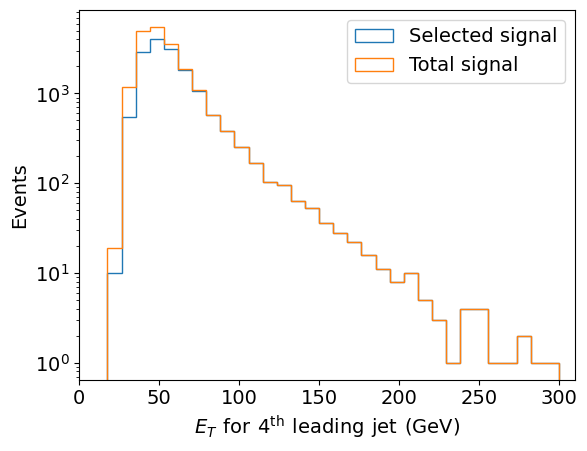

In [58]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_SignalEnergies.png", bbox_inches='tight')
plt.show()

In [59]:
bins=np.linspace(0.1,300,35)
selected_counts, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency = []
energy = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    energy.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

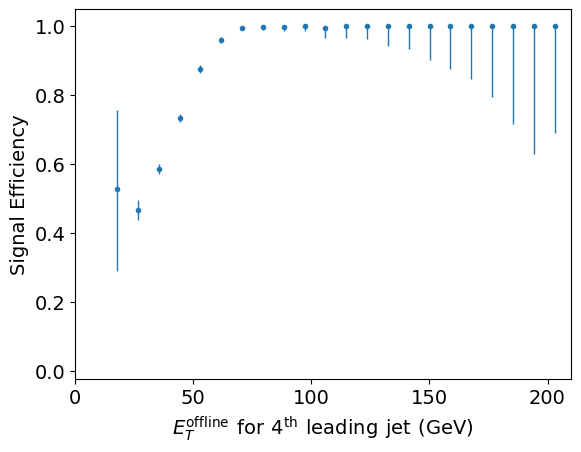

In [60]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_TurnOn.png", bbox_inches='tight')
plt.show()

In [61]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_pt4.npz', energy=energy, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

## Invariant mass of the bbbb system

In [62]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i][1] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut and y_test[i][1] == 1:
        selected_mass.append(mass_test[i])

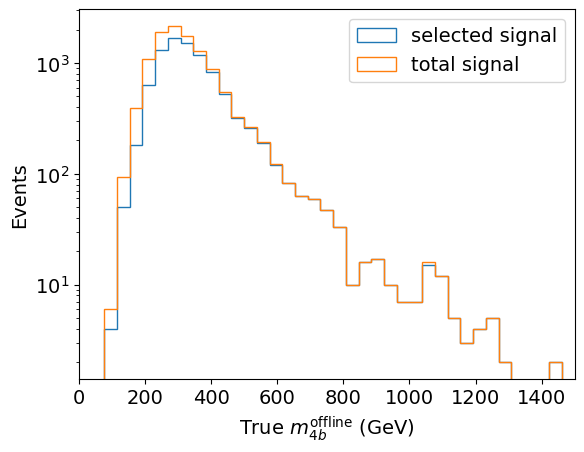

In [63]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_SignalMass.png", bbox_inches='tight')
plt.show()

In [64]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

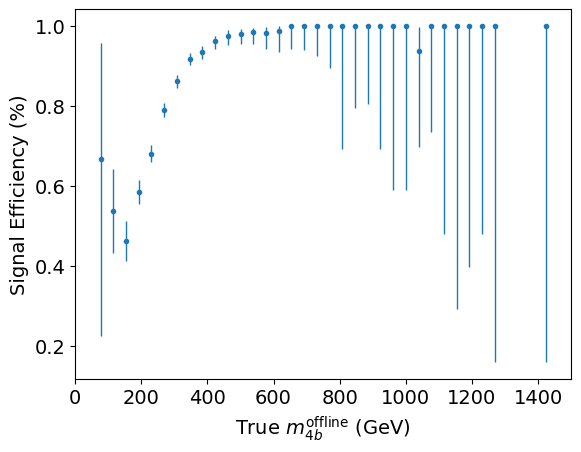

In [65]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_PFN_TurnOn_mass.png", bbox_inches='tight')
plt.show()

In [66]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# XI - Baseline pT cut

In this section, we apply a cut on the fourth-leading jet pT (offline or L1 trigger) to distinguish signal and background - this simulates a standard multijet trigger with a transverse momentum cut.

In [78]:
sig_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
pt4_bkg_offline = pt4_offline[bkg_idx]
pt4_sig_offline = pt4_offline[sig_idx]

In [72]:
pt_fourth_leading_jet_bkg = pt_fourth_leading_jet[:len(bkg_efp_sw)]
pt_fourth_leading_jet_sig = pt_fourth_leading_jet[len(bkg_efp_sw):]

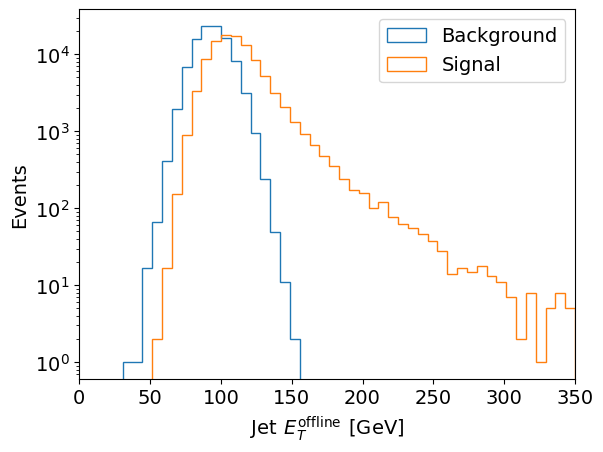

In [75]:
# Plot distribution of the offline energy of the fourth leading jet
# for signal and background
plt.hist(pt_fourth_leading_jet_bkg, bins = np.linspace(10,350,50), histtype='step', label='Background')
plt.hist(pt_fourth_leading_jet_sig, bins = np.linspace(10,350,50),  histtype='step',label='Signal')
plt.xlim(0, 350)
plt.yscale('log')
plt.xlabel(r'$\mathrm{Jet} \hspace{0.4} E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{[GeV]}$')
plt.ylabel('Events')
plt.legend()
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/L1TriggerJets_pt4.png", bbox_inches='tight')
plt.show()

In [77]:
# Select energy threshold for 5% background acceptance
# Define histogram for bkg ET4(offline)
bins = np.linspace(0.01,300,35)
counts, edges = np.histogram(pt_fourth_leading_jet_bkg, bins = bins)
# Calculate histogram integral
total_integral = np.sum(counts)
# Calculate the bkg efficiency for each threshold
thresholds = []
background_efficiency = []
bkg_counts = 0
for i in range(len(counts)):
  bkg_counts += counts[i]
  if total_integral != 0:
    bkg_acceptance = bkg_counts/total_integral
    background_efficiency.append(bkg_acceptance)
    cut = edges[i+1]
    thresholds.append(cut)
    if bkg_acceptance >= 0.95:
      threshold = cut
      break
print(f'The 5% acceptance threshold is: {threshold:.4f}')

The 5% acceptance threshold is: 114.7121


In [79]:
tot_sig_energies = []
sel_sig_energies = []

for i in range(len(pt_fourth_leading_jet_sig)):
  if pt_fourth_leading_jet_sig[i] != 0:
    tot_sig_energies.append(pt4_sig_offline[i])
    if pt_fourth_leading_jet_sig[i] >= threshold:
      sel_sig_energies.append(pt4_sig_offline[i])

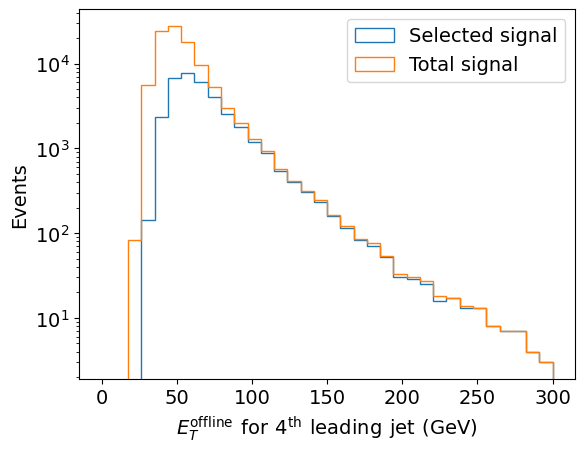

In [80]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(sel_sig_energies, bins=np.linspace(0.01,300,35), histtype='step', label='Selected signal')
plt.hist(tot_sig_energies, bins=np.linspace(0.01,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
#plt.xlim(0,320)
plt.legend()
plt.show()

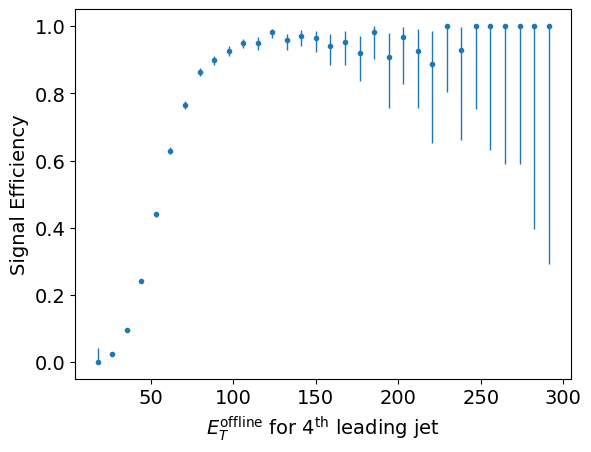

In [81]:
# Define histograms of the energies
bins=np.linspace(0.01,300,35)
selected_counts, edges = np.histogram(sel_sig_energies, bins=bins)
signal_counts, edges1 = np.histogram(tot_sig_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_pt = []
energy_pt = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency_pt.append(sel_sig_i/sig_i)
    energy_pt.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_pt, ci_upp_pt = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low_pt = signal_efficiency_pt - ci_low_pt
err_upp_pt = ci_upp_pt - signal_efficiency_pt
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_pt, signal_efficiency_pt, yerr=[err_low_pt, err_upp_pt], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}}$ for $4^{\mathrm{th}}$ leading jet')
plt.ylabel('Signal Efficiency')
plt.show()

In [82]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_baseline_pt4.npz', energy=energy_pt, signal_eff=signal_efficiency_pt, err_low=err_low_pt, err_upp=err_upp_pt)

## Invariant mass of the bbbb system

In [84]:
sig_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
mass_bkg_offline = true_mass_offline[bkg_idx]
mass_sig_offline = true_mass_offline[sig_idx]

In [85]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(pt_fourth_leading_jet_sig)):
  if pt_fourth_leading_jet_sig[i] != 0:
      signal_mass.append(mass_sig_offline[i])
      if pt_fourth_leading_jet_sig[i] >= threshold: 
        selected_mass.append(mass_sig_offline[i])

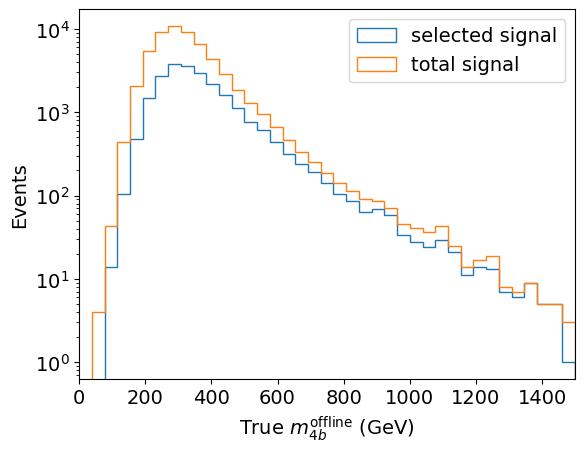

In [86]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [87]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

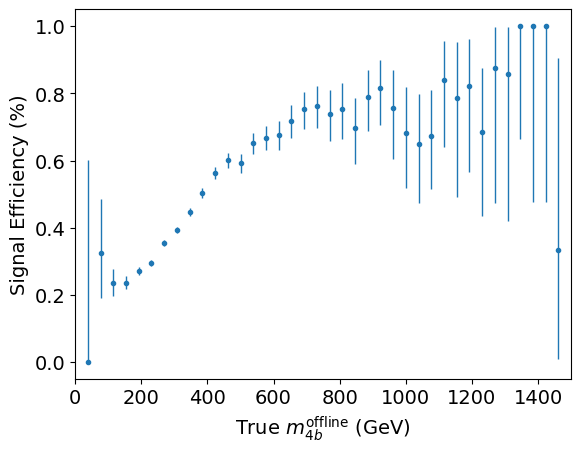

In [88]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.show()

In [89]:
np.savez('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_baseline_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# XII - Turn-on comparison (Offline Jets)

In this section, we compare the turn-on curves for the different selection methods.

In [95]:
offline_jets_lda_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_lda_pt4.npz')
offline_energy = offline_jets_lda_pt4['energy']
offline_signal_efficiency = offline_jets_lda_pt4['signal_eff']
offline_err_low = offline_jets_lda_pt4['err_low']
offline_err_upp = offline_jets_lda_pt4['err_upp']

In [96]:
baseline_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_baseline_pt4.npz')
baseline_energy = baseline_pt4['energy']
baseline_signal_efficiency = baseline_pt4['signal_eff']
baseline_err_low = baseline_pt4['err_low']
baseline_err_upp = baseline_pt4['err_upp']

In [105]:
offline_jets_pfn_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_pfn_pt4.npz')
energy_pfn = offline_jets_pfn_pt4['energy']
signal_efficiency_pfn = offline_jets_pfn_pt4['signal_eff']
err_low_pfn = offline_jets_pfn_pt4['err_low']
err_upp_pfn = offline_jets_pfn_pt4['err_upp']

In [116]:
signal_energies = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/signal_energies.npy')

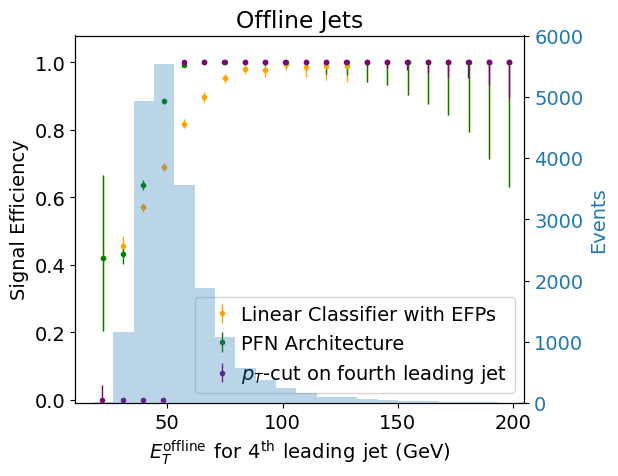

In [119]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
ax1.set_xlim(10,205)
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(offline_energy+4.2, offline_signal_efficiency, yerr=[offline_err_low, offline_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+4.2, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+4.2, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax2.set_ylim(0,6000)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_energies, bins=np.linspace(0.1,300,35), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()
plt.title('Offline Jets')
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/OfflineJets_TurnOn_comparison.png", bbox_inches='tight')
plt.show()

## Invariant mass

In [126]:
offline_jets_lda_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_lda_mass.npz')
offline_energy = offline_jets_lda_mass['energy']
offline_signal_efficiency = offline_jets_lda_mass['signal_eff']
offline_err_low = offline_jets_lda_mass['err_low']
offline_err_upp = offline_jets_lda_mass['err_upp']

In [127]:
baseline_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_baseline_mass.npz')
baseline_energy = baseline_mass['energy']
baseline_signal_efficiency = baseline_mass['signal_eff']
baseline_err_low = baseline_mass['err_low']
baseline_err_upp = baseline_mass['err_upp']

In [128]:
offline_jets_pfn_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/offline_jets_pfn_mass.npz')
energy_pfn = offline_jets_pfn_mass['energy']
signal_efficiency_pfn = offline_jets_pfn_mass['signal_eff']
err_low_pfn = offline_jets_pfn_mass['err_low']
err_upp_pfn = offline_jets_pfn_mass['err_upp']

In [129]:
signal_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/signal_mass.npy')

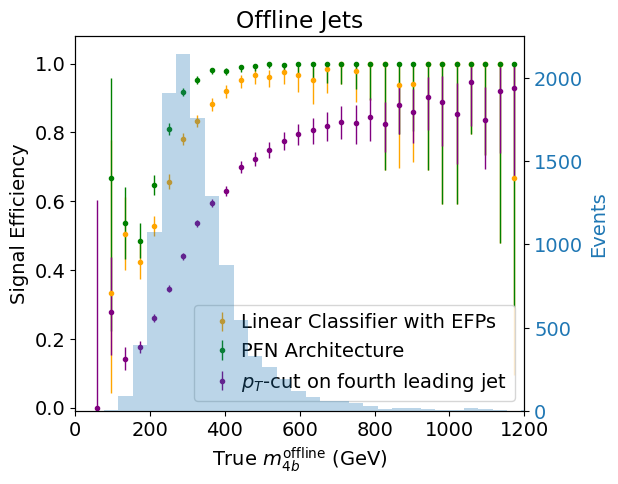

In [131]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(offline_energy+18.75, offline_signal_efficiency, yerr=[offline_err_low, offline_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+18.75, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+18.75, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax1.set_xlim(0,1200)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()
plt.title('Offline Jets')
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/OfflineJets_TurnOn_comparison_mass.png", bbox_inches='tight')
plt.show()

# XIII - Turn-on comparison (L1 Trigger Jets)

In [101]:
trigger_jets_lda_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_lda_pt4.npz')
trigger_energy = trigger_jets_lda_pt4['energy']
trigger_signal_efficiency = trigger_jets_lda_pt4['signal_eff']
trigger_err_low = trigger_jets_lda_pt4['err_low']
trigger_err_upp = trigger_jets_lda_pt4['err_upp']

In [102]:
baseline_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_baseline_pt4.npz')
baseline_energy = baseline_pt4['energy']
baseline_signal_efficiency = baseline_pt4['signal_eff']
baseline_err_low = baseline_pt4['err_low']
baseline_err_upp = baseline_pt4['err_upp']

In [103]:
trigger_jets_pfn_pt4 = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_pt4.npz')
energy_pfn = trigger_jets_pfn_pt4['energy']
signal_efficiency_pfn = trigger_jets_pfn_pt4['signal_eff']
err_low_pfn = trigger_jets_pfn_pt4['err_low']
err_upp_pfn = trigger_jets_pfn_pt4['err_upp']

In [104]:
signal_energies = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_signal_energies.npy')

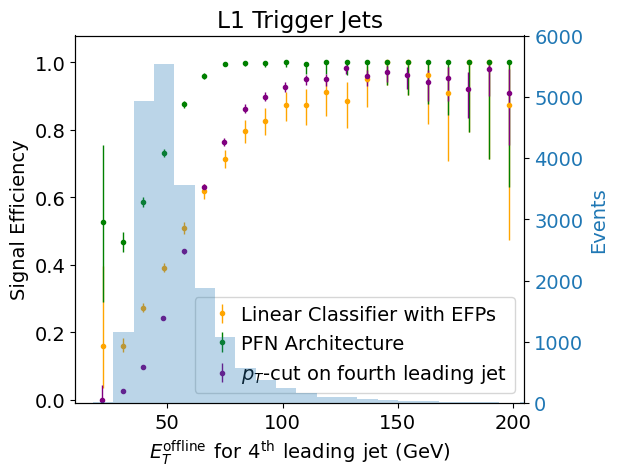

In [105]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
ax1.set_xlim(10,205)
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(trigger_energy+4.2, trigger_signal_efficiency, yerr=[trigger_err_low, trigger_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+4.2, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+4.2, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax2.set_ylim(0,6000)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_energies, bins=np.linspace(0.1,300,35), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()
plt.title('L1 Trigger Jets')
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/l1TriggerJets_TurnOn_comparison.png", bbox_inches='tight')
plt.show()

## Invariant mass

In [106]:
trigger_jets_lda_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_lda_mass.npz')
trigger_energy = trigger_jets_lda_mass['energy']
trigger_signal_efficiency = trigger_jets_lda_mass['signal_eff']
trigger_err_low = trigger_jets_lda_mass['err_low']
trigger_err_upp = trigger_jets_lda_mass['err_upp']

In [107]:
baseline_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_baseline_mass.npz')
baseline_energy = baseline_mass['energy']
baseline_signal_efficiency = baseline_mass['signal_eff']
baseline_err_low = baseline_mass['err_low']
baseline_err_upp = baseline_mass['err_upp']

In [108]:
trigger_jets_pfn_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_pfn_mass.npz')
energy_pfn = trigger_jets_pfn_mass['energy']
signal_efficiency_pfn = trigger_jets_pfn_mass['signal_eff']
err_low_pfn = trigger_jets_pfn_mass['err_low']
err_upp_pfn = trigger_jets_pfn_mass['err_upp']

In [109]:
signal_mass = np.load('/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/arrays_for_plots/trigger_jets_signal_mass.npy')

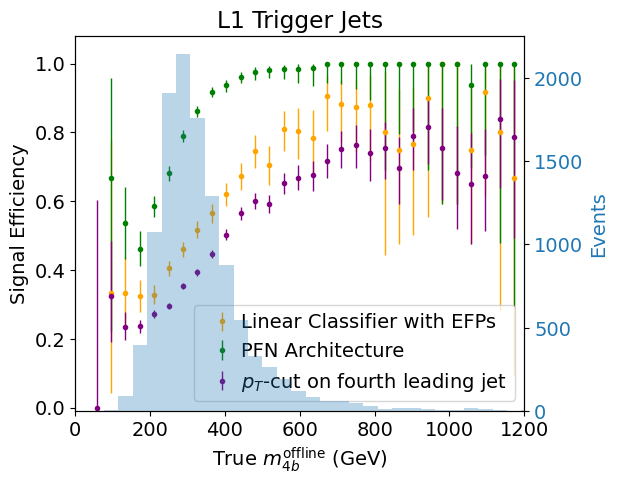

In [110]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(trigger_energy+18.75, trigger_signal_efficiency, yerr=[trigger_err_low, trigger_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+18.75, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+18.75, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax1.set_xlim(0,1200)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()
plt.title('L1 Trigger Jets')
plt.savefig("/lstore/titan/atlas/aritafc/EnergyFlowAnalysis/plots/l1TriggerJets_TurnOn_comparison_mass.png", bbox_inches='tight')
plt.show()